# Topic categories 

Create the topic to extract key word from the ovewrview to classify the movies / series by topics 

In [16]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("DATA/PROCESSED/all_streaming_titles.csv")

# -----------------------------
# 1. Define topic keywords
# -----------------------------
topics = {
    "lgbtq": [
        "gay", "lesbian", "lgbt", "trans", "queer", "bisexual",
        "nonbinary", "coming out", "drag", "identity"
    ],

    "politics": [
        "politics", "president", "government", "election", "policy",
        "senate", "congress", "campaign", "minister", "dictator",
        "democracy", "corruption", "power", "state"
    ],

    "climate_environment": [
        "climate", "environment", "global warming", "pollution",
        "ecology", "sustainability", "nature", "forest", "wildlife",
        "environmental disaster", "carbon", "climate crisis"
    ],

    "war_military": [
        "war", "battle", "army", "soldier", "military", "conflict",
        "weapon", "navy", "air force", "commander", "resistance",
        "invasion", "combat", "veteran"
    ],

    "family": [
        "family", "mother", "father", "parent", "children", "child",
        "home", "siblings", "brother", "sister", "marriage",
        "divorce", "parenthood", "relatives"
    ],

    "crime": [
        "crime", "murder", "police", "detective", "investigation",
        "killer", "gang", "mafia", "cartel", "robbery", "heist",
        "forensics", "prison", "criminal", "underworld"
    ],

    "policial": [
        "police", "cop", "officer", "detective", "agent", "rookie",
        "investigation", "investigator", "inspector", "sergeant",
        "lieutenant", "captain", "chief", "precinct", "partner",
        "case", "crime scene", "forensics", "suspect", "witness",
        "interrogation", "undercover", "surveillance", "homicide",
        "manhunt", "law enforcement", "special unit", "task force",
        "fbi", "cia", "narcotics", "patrol", "unit"
    ],

    "romance": [
        "love", "romance", "relationship", "couple", "passion",
        "heartbreak", "dating", "affair", "wedding", "breakup",
        "soulmate", "jealousy"
    ],

    "technology": [
        "technology", "ai", "artificial intelligence", "robot",
        "future", "cyber", "computer", "hacker", "internet",
        "virtual reality", "machine", "automation", "surveillance"
    ],

    "mental_health": [
        "depression", "anxiety", "trauma", "therapy", "mental",
        "psychological", "stress", "grief", "addiction", "bipolar",
        "schizophrenia", "panic", "healing", "psychiatric"
    ],

    "coming_of_age": [
        "teen", "adolescent", "growing up", "school", "youth",
        "friendship", "identity", "first love", "high school",
        "college", "self-discovery", "maturity"
    ],

    "social_issues": [
        "racism", "inequality", "poverty", "discrimination", "justice",
        "migration", "sexism", "class", "homophobia", "xenophobia",
        "oppression", "human rights", "activism"
    ],

    "fantasy_supernatural": [
        "magic", "witch", "dragon", "supernatural", "monster",
        "curse", "fantasy", "sorcery", "wizard", "demon", "ghost",
        "prophecy", "kingdom", "spell"
    ],

    "science_fiction": [
        "space", "alien", "spaceship", "future", "planet",
        "time travel", "parallel universe", "android", "mutation",
        "dystopia", "utopia", "interstellar", "extraterrestrial"
    ],

    "horror": [
        "horror", "fear", "haunted", "ghost", "possession",
        "slasher", "evil", "demon", "nightmare", "blood",
        "terror", "zombie", "paranormal"
    ],

    "thriller": [
        "thriller", "suspense", "mystery", "conspiracy", "chase",
        "secret", "obsession", "danger", "kidnapping", "betrayal",
        "tension", "survival"
    ],

    "action_adventure": [
        "action", "adventure", "hero", "mission", "explosion",
        "fight", "chase", "survival", "escape", "journey",
        "quest", "mercenary"
    ],

    "historical": [
        "history", "historical", "period drama", "king", "queen",
        "empire", "revolution", "civilization", "medieval",
        "ancient", "biographical", "royalty"
    ],

    "biography": [
        "biography", "biopic", "true story", "real life", "famous",
        "artist", "scientist", "politician", "athlete", "inventor"
    ],

    "sports": [
        "sport", "football", "soccer", "basketball", "baseball",
        "tennis", "boxing", "fighter", "competition", "tournament",
        "coach", "team", "championship"
    ],

    "music_performance": [
        "music", "band", "singer", "concert", "performance",
        "musician", "song", "dance", "ballet", "opera",
        "stage", "show business"
    ],

    "comedy": [
        "comedy", "funny", "humor", "satire", "parody",
        "awkward", "absurd", "joke", "laugh", "misunderstanding"
    ],

    "drama": [
        "drama", "emotional", "conflict", "sacrifice", "loss",
        "betrayal", "redemption", "personal struggle", "intense"
    ],

    "mystery": [
        "mystery", "secret", "clue", "disappearance", "puzzle",
        "unknown", "hidden truth", "unsolved", "investigation"
    ],

    "survival_disaster": [
        "survival", "disaster", "earthquake", "tsunami", "fire",
        "shipwreck", "plane crash", "apocalypse", "epidemic",
        "outbreak", "catastrophe"
    ],

    "religion_spirituality": [
        "religion", "faith", "god", "church", "priest", "spiritual",
        "belief", "miracle", "sacred", "ritual", "afterlife"
    ],

    "animation_family": [
        "animation", "animated", "family-friendly", "kids",
        "talking animals", "fairy tale", "adventure for children"
    ],

    "friendship": [
        "friendship", "best friends", "companionship", "bond",
        "loyalty", "group of friends", "reunion"
    ],

    "revenge": [
        "revenge", "vengeance", "payback", "betrayal", "justice",
        "retaliation", "avenger"
    ],

    "road_trip_journey": [
        "road trip", "journey", "travel", "on the road", "escape",
        "self-discovery", "destination"
    ],

    "school_university": [
        "school", "teacher", "student", "classroom", "university",
        "college", "campus", "exam", "bullying", "graduation"
    ],

    "work_business": [
        "work", "office", "career", "boss", "company", "business",
        "corporate", "startup", "ambition", "promotion", "colleague"
    ]
}

# -----------------------------
# 2. Clean overview text
# -----------------------------
df["overview_clean"] = df["overview"].fillna("").str.lower()

# -----------------------------
# 3. Create topic columns
# -----------------------------
for topic, keywords in topics.items():
    df[f"topic_{topic}"] = df["overview_clean"].apply(
        lambda x: int(any(keyword in x for keyword in keywords))
    )

topic_cols = [col for col in df.columns if col.startswith("topic_")]

df["topic_diversity_score"] = df[topic_cols].sum(axis=1)  

print(df[[col for col in df.columns if "topic_" in col]].head())

   topic_lgbtq  topic_politics  topic_climate_environment  topic_war_military  \
0            0               0                          0                   0   
1            0               0                          0                   1   
2            0               0                          0                   0   
3            0               0                          0                   1   
4            0               0                          0                   1   

   topic_family  topic_crime  topic_policial  topic_romance  topic_technology  \
0             0            0               1              0                 0   
1             0            0               1              0                 1   
2             0            0               0              0                 0   
3             1            0               0              0                 1   
4             0            0               0              0                 0   

   topic_mental_health  ..

# K-Means Clustering (Main Model)

Select Features


We selected variables that represent key marketing dimensions:

- Popularity → visibility
- Vote count → engagement
- Vote average → audience reception
- Business value score → commercial potential
- Topic diversity → thematic richness

These features allow the model to group content based on performance and positioning, not irrelevant attributes.

In [17]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Prepare features and target 
# -----------------------------

features = ["popularity", 
            "vote_average", 
            "vote_count", 
            "business_value_score",
            "topic_diversity_score"]  # Add topic diversity score as a feature


x=df[features].fillna(0)  # Fill NaN values with 0 for features

Scale Data

We applied standardization using StandardScaler.

This is critical because K-Means relies on distance calculations.


Without scaling:

- Variables with larger ranges (e.g., vote_count) would dominate
- Smaller-scale variables (e.g., vote_average) would be ignored


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=features, index=df.index)

x_scaled.head()

,popularity,vote_average,vote_count,business_value_score,topic_diversity_score
0,41.229983,1.912076,2.537551,17.374315,-0.156783
1,45.023140,0.429315,0.663575,17.275144,0.227387
2,35.814996,1.544544,9.350809,17.172639,-1.309290
3,37.339901,1.649061,7.126287,17.004700,0.611556
4,19.962510,1.830530,23.111747,16.742321,0.227387


Find optimal K (Elbow method)

Choosing the Number of Clusters (Elbow Method)

We tested different values of K and used the Elbow Method.

The goal is to find a balance between:

- model simplicity
- cluster compactness (low inertia)


K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Inertia: [385754.0758779769, 296474.01711353025, 232335.583551441, 190109.97456042297, 162136.6569209421, 137400.33664729784, 120979.546414758, 106750.04684074063, 95290.34142096262]
kmeans_cluster
0    65311
4    27475
1     2230
2      636
3      548
Name: count, dtype: int64


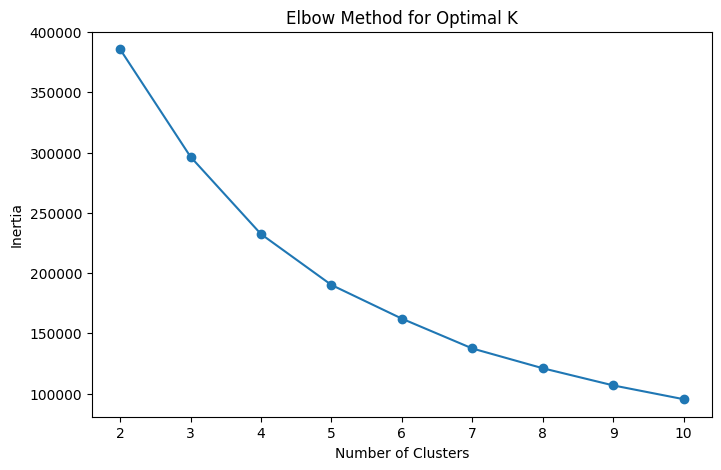

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Evaluate inertia across a range of cluster counts
k_values = range(2, 11)
inertia = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

print("K values:", list(k_values))
print("Inertia:", inertia)

# Fit final KMeans model
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(x_scaled)

print(df["kmeans_cluster"].value_counts())

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

What it shows

On the X-axis is the number of clusters (K), and on the Y-axis is the inertia.

I can see that:
- from 2 to 3 it drops a lot,
- from 3 to 4 it drops quite a bit,
- from 4 to 5 it keeps decreasing,
- after 5 the curve starts to flatten more.

Interpretation

The graph suggests that the “elbow” is around 4 or 5.

That means:

with 4 or 5 clusters, you already capture a good part of the structure, adding more clusters brings smaller improvements.


between 4 and 5 is the optimal number 

# Train Final Model

We trained the K-Means model and assigned each title to a cluster.

Each cluster represents a group of content with similar characteristics.


In [20]:
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_final.fit(x_scaled)

df["kmeans_cluster"] = kmeans_final.fit_predict(x_scaled)

print(df["kmeans_cluster"].value_counts())
pd.DataFrame(kmeans_final.cluster_centers_, columns=features)

kmeans_cluster
0    65311
4    27475
1     2230
2      636
3      548
Name: count, dtype: int64


,popularity,vote_average,vote_count,business_value_score,topic_diversity_score
0,-0.080949,0.120026,-0.073201,0.032324,-0.537993
1,0.544399,-5.160607,-0.128218,-3.817763,-0.134732
2,1.193028,0.529118,9.957466,4.245032,0.171815
3,9.298734,0.528644,0.826922,3.853574,0.135551
4,-0.064844,0.110753,-0.062579,0.057904,1.283121


Interpret clusters 

We analyzed the average values of each cluster to understand their profiles.

Examples:
- High visibility + high engagement → blockbuster content
- Low visibility + high ratings → niche quality content
- Low everything → low-performing titles


In [21]:
topic_cols = [col for col in df.columns if col.startswith("topic_")]

cluster_counts = df["kmeans_cluster"].value_counts().sort_index()
cluster_feature_means = df.groupby("kmeans_cluster")[features].mean().round(3)
cluster_topic_means = df.groupby("kmeans_cluster")[topic_cols].mean()

print("Cluster counts:")
print(cluster_counts)
print("\nCluster feature means:")
print(cluster_feature_means)

print("\nCluster topic prevalence (top 5 topics per cluster):")
for cluster, row in cluster_topic_means.iterrows():
    top_topics = row.sort_values(ascending=False).head(5)
    print(f"\nCluster {cluster}:")
    print(top_topics)

Cluster counts:
kmeans_cluster
0    65311
1     2230
2      636
3      548
4    27475
Name: count, dtype: int64

Cluster feature means:
                popularity  vote_average  vote_count  business_value_score  \
kmeans_cluster                                                               
0                    1.171         6.969      77.385                22.912   
1                    6.984         2.371      14.763                13.509   
2                   13.014         7.325   11494.509                33.200   
3                   88.364         7.324    1101.925                32.244   
4                    1.321         6.961      89.476                22.974   

                topic_diversity_score  
kmeans_cluster                         
0                               2.008  
1                               3.057  
2                               3.855  
3                               3.761  
4                               6.748  

Cluster topic prevalence (top 5 topi

label Clusters

We translated clusters into meaningful marketing labels:
- High Value Content
- High Visibility
- Quality Niche
- Low Performance


This step is key to bridge technical output and business insights.


In [22]:
def label_cluster(row):
    if row["business_value_score"] > 70:
        return "High Value Content"
    elif row["popularity"] > df["popularity"].median():
        return "High Visibility"
    elif row["vote_average"] > 7:
        return "Quality Niche"
    else:
        return "Low Performance"

df["cluster_label"] = df.apply(label_cluster, axis=1)

# Visualize Clusters

/Users/blanca/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


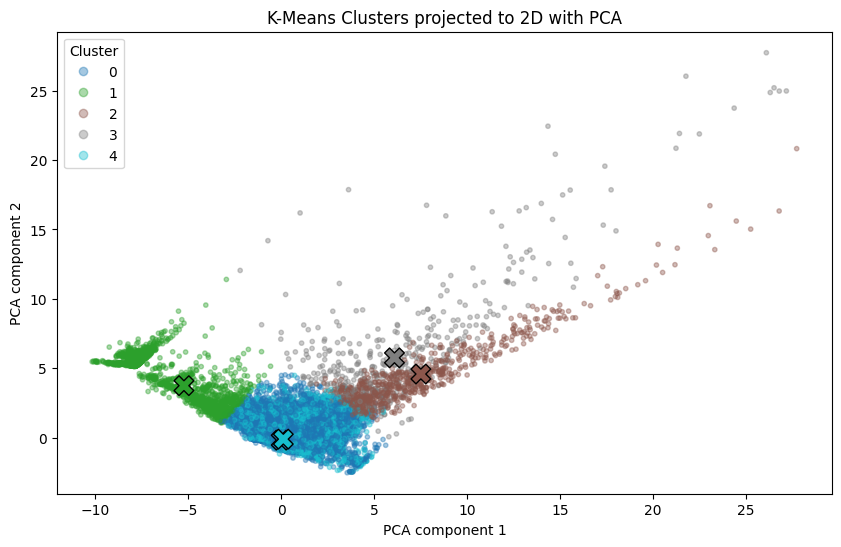

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaled)

centers_pca = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=df["kmeans_cluster"],
    cmap="tab10",
    alpha=0.4,
    s=10
)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c=range(n_clusters),
    cmap="tab10",
    s=200,
    marker="X",
    edgecolor="k"
)
plt.title("K-Means Clusters projected to 2D with PCA")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

What it shows

- This chart projects the main clustering into 2 dimensions using PCA.
- Each point is a title.
- Each color is a cluster.
- The large X’s are the centroids.

What we observe

There is a reasonable separation between groups, although not a perfect one.
That is normal in real clustering.
Clusters do not always appear as “fully separated islands.”
The gray and brown clusters seem to extend toward the upper-right area.
That suggests they group titles with more extreme profiles in some combination of variables.
Possibly titles with higher performance, higher value, or more marked characteristics.
The blue/cyan cluster in the lower-central area seems to concentrate many more “average” or less differentiated titles.
It is common for one cluster to group the bulk of the catalog.
There is a fan- or triangle-like structure, which indicates that the dataset has internal gradients.
These are not completely closed groups, but rather profiles that change progressively.


Business interpretation

there is internal segmentation in the catalog,
but it is not an absolutely rigid separation,
rather, there are families of content with some continuity between them.


Important
Because this is PCA:
the axes PCA component 1 and PCA component 2 do not have a simple direct interpretation such as “popularity” or “quality.”
They are mathematical combinations of the original variables.


So this chart is more useful for:
seeing the overall structure
and confirming that the clustering makes visual sense.


engage_vis_cluster
0    82496
1    12612
2      631
3      461
Name: count, dtype: int64
                    engagement_score  visibility_score
engage_vis_cluster                                    
0                             49.998            50.000
1                              1.538             2.241
2                             28.587             2.563
3                              2.520            21.118


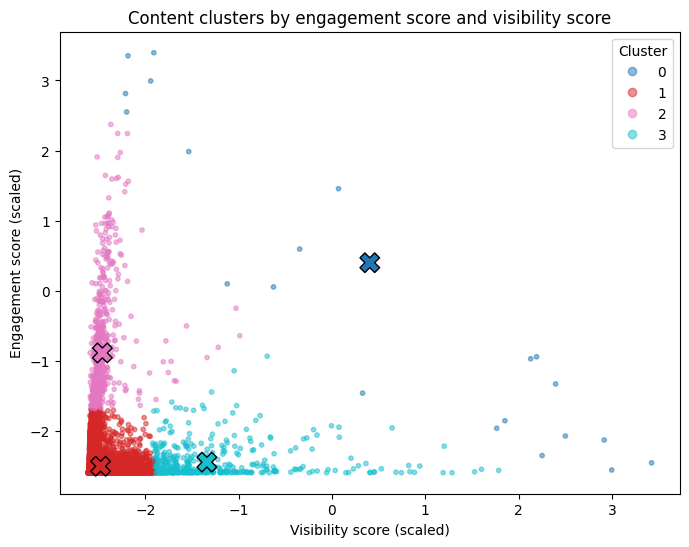

In [24]:
features_ev = ["engagement_score", "visibility_score"]
x_ev = df[features_ev].fillna(0)

scaler_ev = StandardScaler()
x_ev_scaled = pd.DataFrame(
	scaler_ev.fit_transform(x_ev),
	columns=features_ev,
	index=df.index
)

n_clusters_ev = 4
kmeans_ev = KMeans(n_clusters=n_clusters_ev, random_state=42, n_init=10)
df["engage_vis_cluster"] = kmeans_ev.fit_predict(x_ev_scaled)

print(df["engage_vis_cluster"].value_counts())
print(df.groupby("engage_vis_cluster")[features_ev].mean().round(3))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
	x_ev_scaled["visibility_score"],
	x_ev_scaled["engagement_score"],
	c=df["engage_vis_cluster"],
	cmap="tab10",
	alpha=0.5,
	s=10
)
plt.scatter(
	kmeans_ev.cluster_centers_[:, 1],
	kmeans_ev.cluster_centers_[:, 0],
	c=range(n_clusters_ev),
	cmap="tab10",
	s=200,
	marker="X",
	edgecolor="k"
)
plt.xlabel("Visibility score (scaled)")
plt.ylabel("Engagement score (scaled)")
plt.title("Content clusters by engagement score and visibility score")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

What it shows
X-axis: scaled visibility_score
Y-axis: scaled engagement_score
Colors: clusters
Large X’s: centroids

General reading
Here, you are grouping titles based on two questions:
- How visible are they?
- How much response/interaction do they generate?

# Dark blue cluster (centroid in the upper-right)
This cluster is close to:
relatively high visibility
relatively high engagement

Interpretation

This is the strongest content group on both dimensions.
You could describe it as:
high-potential / standout content
titles that are not only seen, but also generate response

Business meaning
This is content worth:
promoting,
protecting,
turning into a reference point,
using as a benchmark.

# Red cluster (bottom-left, very extreme)
This one shows:
low visibility
very low engagement

Interpretation
This is the low-performance group.

Business meaning
These titles:
are not reaching many people,
and they are not triggering much interaction either.
This may include:
less attractive content,
poorly exposed content,
or simply long-tail catalog titles.

# Pink cluster (left side, but higher in engagement)
This cluster has:
low visibility
but relatively better engagement than other low-performing groups

Interpretation
This one is very interesting: it looks like engaged niche content.
It does not necessarily reach many people, but the people who do find it respond better.

Business meaning
It could correspond to:
specific fandoms,
niche genres,
titles with a small but loyal community.
This is often valuable because:
they are not mainstream,
but they can show strong affinity,
and with better distribution they might scale.

# Light blue cluster (lower-right / lower-center)

This one seems to have:
somewhat more visibility than the red/pink clusters in several cases,
but very low engagement

Interpretation
It sounds like high awareness, weak conversion / weak interaction.
In other words:
the content is being exposed,
but it is not turning that exposure into response.

Business meaning
This cluster is usually very useful because it highlights titles where there is:
awareness without connection,
initial curiosity but little depth,
or marketing that creates reach but not engagement.
It could suggest:
reviewing the creatives,
reviewing the positioning,
reviewing whether the content promises something it does not actually deliver.



# Marketing Insights

In [25]:
topic_cols_no_diversity = [c for c in topic_cols if c != "topic_diversity_score"]

cluster_label_insights = df.groupby("cluster_label").agg(
	count=("title", "size"),
	popularity_mean=("popularity", "mean"),
	vote_average_mean=("vote_average", "mean"),
	vote_count_mean=("vote_count", "mean"),
	business_value_score_mean=("business_value_score", "mean"),
	topic_diversity_score_mean=("topic_diversity_score", "mean"),
).sort_values("count", ascending=False)

cluster_label_topic_means = df.groupby("cluster_label")[topic_cols_no_diversity].mean()

def top_topics_for_label(label_row, n=5):
	return label_row.sort_values(ascending=False).head(n).index.tolist()

top_topics_by_label = {
	label: top_topics_for_label(row)
	for label, row in cluster_label_topic_means.iterrows()
}

cluster_label_insights["top_topics"] = cluster_label_insights.index.map(
	lambda label: top_topics_by_label[label]
)

cluster_label_insights

,count,popularity_mean,vote_average_mean,vote_count_mean,business_value_score_mean,topic_diversity_score_mean,top_topics
cluster_label,,,,,,,
Low Performance,78657,0.000000,6.927699,0.000000,22.736848,3.319654,"[topic_technology, topic_family, topic_policia..."
High Visibility,13725,13.481577,6.304905,1126.392568,23.071785,3.570783,"[topic_technology, topic_family, topic_policia..."
Quality Niche,3818,0.000000,7.566763,0.000000,23.948583,4.645626,"[topic_technology, topic_policial, topic_famil..."


# Save Final model

In [26]:
import os
import joblib

os.makedirs("MODELS", exist_ok=True)

joblib.dump(kmeans_final, "MODELS/kmeans_final.joblib")
joblib.dump(scaler, "MODELS/kmeans_scaler.joblib")

# optional: save the engagement/visibility model as well
joblib.dump(kmeans_ev, "MODELS/kmeans_engage_vis.joblib")
joblib.dump(scaler_ev, "MODELS/scaler_ev.joblib")

print("Models saved to models/")

Models saved to models/


# Save CSV for regression

In [27]:
# Save the dataframe with cluster assignments and predictions to CSV
df.to_csv("DATA/PROCESSED/streaming_titles_clustered.csv", index=False)

print("Clustered data saved to DATA/PROCESSED/streaming_titles_clustered.csv")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.shape[1]}")

Clustered data saved to DATA/PROCESSED/streaming_titles_clustered.csv
Total rows: 96200
Columns: 78
